ganda pedro


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

This next cell was run once locally in one of the computers to compress the data into .gz files, as the original files were too big to pass GitHub's size limits. This way, all the code can be ran with the repositories contents (deliverables in this case).

In [ ]:
#pd.read_csv("data/train.csv").to_csv("data/train.csv.gz", index=False, compression="gzip")
#pd.read_csv("data/test.csv").to_csv("data/test.csv.gz", index=False, compression="gzip")

In [21]:
train_data = pd.read_csv('data/train.csv.gz')
test_data = pd.read_csv('data/test.csv.gz')

In [24]:
display(train_data)
display(test_data.head())

,title,tag,artist,year,views,features,lyrics,id
0,Walk Away,rock,Tony Molina,2013,699,{},When you said you loved me\nDid you mean it th...,535805
1,Gotta Make It Kid Naruto Rap,rap,Reece Lett,2021,4,{Sl!ck},Kid Naruto Rap\n[Hook]\nEverybody wants you to...,7519483
2,​this is what i asked for,pop,Elliot (DNK),2019,389,{},[Verse 1]\nPeople tell me I've changed\nI find...,4892808
3,Stealing Hearts,pop,Katie Armiger,2013,126,{},You've been warned about me\nDon't try to get ...,1584150
4,Get Ready,country,John Campbell Munro,1,2,{},[Verse 1]\nI can see the end is coming but I’v...,7639050
...,...,...,...,...,...,...,...,...
134962,Manhattan,pop,Tijuana Sweetheart,2007,48,{},If I knew when I was young that I'd be older\n...,1702980
134963,Belly Shit,rap,Lil Gotit,2019,3593,"{""Lil Troup""}",[Intro: Lil Gotit]\nCash\nWah-wah-wah\nWah-wah...,4802970
134964,The Four Loves,rock,Heath McNease,2014,301,{},[Verse 1]\nI was born inside a home\nThe young...,403929
134965,Ball And Chain,pop,Transmatic,2001,46,{},Rollin' by the pool the falling stars are not ...,1000723


,title,artist,year,views,features,lyrics,id
0,Like You Do,Jimmie Allen,2018,825,{},[Verse 1]\nYour head's on my chest\nThis bed's...,3996359
1,This Building is Falling Down,The Taxpayers,2009,400,{},Epilogue: A sound off from simple people with ...,3553166
2,My Private Joy,Dion and The Belmonts,1960,229,{},[Verse 1]\nOh well Susie is a doozy with a pon...,2998742
3,Vegan,Yung Kurry,2018,1041,{},Hook\nShe a vegan but she eat my meat with no ...,3993470
4,To The Boy I Used To Know,Angelina Cruz,2018,63,{},To the boy I used to know\nI wonder how do you...,5488256


In [34]:
train_data.loc[train_data['year'] < 1900, 'year'] = np.nan

In [31]:
# Isolate years before 1900 and count their frequencies
weird_years = train_data[train_data['year'] < 1900]['year']
print("Most frequent anomalous years:")
display(weird_years.value_counts().head(10))

Most frequent anomalous years:


1       45
1855    21
1847    19
1868    19
1896    17
1857    13
1874    13
1877    12
1848    11
1812    11
Name: year, dtype: int64

so um grafico pa checkar oq fazer quanto a coluna do year, pq sq nem e relevante de todo

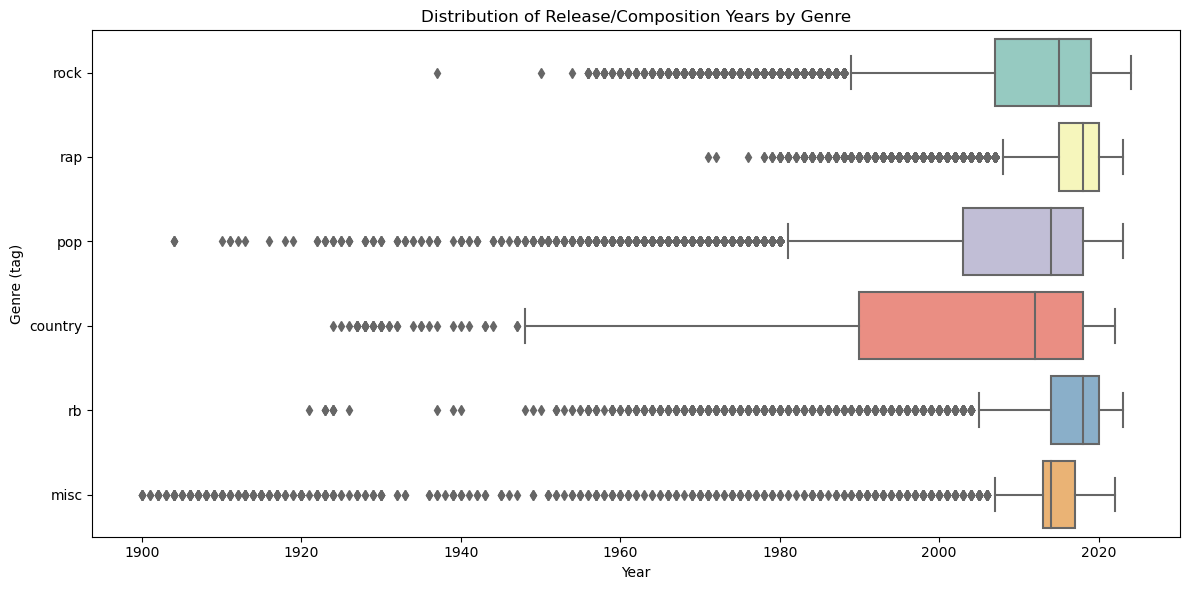

Temporal Summary by Genre:


,median,mean,min,max,count
tag,,,,,
country,2012.0,2002.0,1924.0,2022.0,3465
misc,2014.0,2009.0,1900.0,2022.0,5050
pop,2014.0,2009.0,1904.0,2023.0,55724
rock,2015.0,2010.0,1937.0,2024.0,25328
rap,2018.0,2016.0,1971.0,2023.0,38550
rb,2018.0,2012.0,1921.0,2023.0,6197


In [35]:
# 1. Visualizing the distribution of years per genre
plt.figure(figsize=(12, 6))
# Dropping NaNs just for the plot to avoid errors
sns.boxplot(data=train_data.dropna(subset=['year']), x='year', y='tag', palette='Set3')
plt.title('Distribution of Release/Composition Years by Genre')
plt.xlabel('Year')
plt.ylabel('Genre (tag)')
plt.tight_layout()
plt.show()

# 2. Statistical summary to back up the visual
print("Temporal Summary by Genre:")
year_summary = train_data.groupby('tag')['year'].agg(['median', 'mean', 'min', 'max', 'count']).round(0)
display(year_summary.sort_values(by='median'))